<a href="https://colab.research.google.com/github/Prajit-B/Interpretable-RL-Based-Sleep-Stagging/blob/main/FinalModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ⚡ FULL PERFORMANCE MODE: PPO + RF Feature Selection with SHAP Rank Penalty

!pip install -q "shimmy>=2.0" stable-baselines3[extra] scikit-learn pandas shap

import os
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import gym
from gym import spaces
from google.colab import drive, files

# Mount Google Drive
drive.mount('/content/drive')

# Upload full dataset
print("📄 Upload your FULL CSV (features + label)...")
uploaded = files.upload()
for fname in uploaded:
    input_csv_path = f"/content/{fname}"
    break

output_folder = "/content/drive/MyDrive/selected_features"
os.makedirs(output_folder, exist_ok=True)

# === STEP 1: Compute SHAP feature ranks ===
def compute_shap_feature_ranks(X, y):
    model = RandomForestClassifier(n_estimators=100, random_state=0)
    model.fit(X, y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # === Handle multiclass vs binary ===
    if isinstance(shap_values, list):  # Multiclass
        shap_array = np.stack([np.abs(sv) for sv in shap_values], axis=0)
        mean_abs_shap = shap_array.mean(axis=0)
    else:  # Binary
        mean_abs_shap = np.abs(shap_values)

    if mean_abs_shap.ndim == 3:
        mean_abs_shap = mean_abs_shap.mean(axis=1)

    mean_shap_values = np.mean(mean_abs_shap, axis=0)

    # === Safety check: force length to X.shape[1] ===
    if len(mean_shap_values) != X.shape[1]:
        print(f"⚠️ WARNING: SHAP returned {len(mean_shap_values)} features, but X has {X.shape[1]}. Fixing...")
        # Pad missing features with SHAP=0
        padded = np.zeros(X.shape[1])
        padded[:len(mean_shap_values)] = mean_shap_values
        mean_shap_values = padded

    # === FORCE CORRECT INDEX ===
    feature_ranks = pd.Series(mean_shap_values, index=np.arange(X.shape[1])).rank(ascending=False).astype(int).to_dict()

    return feature_ranks


# === STEP 2: Feature Selection Environment ===
class FeatureSelectionEnv(gym.Env):
    def __init__(self, X, y, feature_ranks, penalty_coef=0.0, test_size=0.3, seed=0):
        super().__init__()
        self.X, self.y = X, y
        self.feature_ranks = feature_ranks  # dict: feature_idx -> rank
        self.n_features = X.shape[1]
        self.penalty_coef = penalty_coef
        self.test_size = test_size
        self.random_seed = seed
        self.action_space = spaces.Discrete(self.n_features)
        self.observation_space = spaces.Box(0, 1, (self.n_features,), dtype=np.int8)
        self.reset()

    def reset(self):
        self.selected = np.zeros(self.n_features, dtype=np.int8)
        self.step_count = 0
        return self.selected.copy()

    def step(self, action):
        if self.selected[action]:
            return self.selected.copy(), -0.01, False, {}

        self.selected[action] = 1
        self.step_count += 1
        done = (self.step_count >= self.n_features)
        reward = 0.0

        if done:
            cols = np.where(self.selected == 1)[0]
            if len(cols) == 0:
                return self.selected.copy(), -1.0, True, {}

            X_sel = self.X[:, cols]
            Xtr, Xte, ytr, yte = train_test_split(X_sel, self.y, test_size=self.test_size, random_state=self.random_seed)

            model = RandomForestClassifier(n_estimators=100, random_state=self.random_seed, n_jobs=-1)
            model.fit(Xtr, ytr)
            acc = accuracy_score(yte, model.predict(Xte))

            # === Compute penalty ===
            rank_penalty = sum([self.feature_ranks[int(idx)] for idx in cols])
            penalty = self.penalty_coef * rank_penalty

            reward = acc - penalty
            print(f"[INFO] Accuracy={acc:.4f}, Penalty={penalty:.4f}, Reward={reward:.4f}, Selected={len(cols)} features")

        return self.selected.copy(), reward, done, {}

    def seed(self, seed=None):
        np.random.seed(seed)

# === STEP 3: PPO Training Function ===
def train_feature_selector(X, y, feature_ranks, total_timesteps=50000, penalty_coef=0.0):
    def make_env():
        return FeatureSelectionEnv(X, y, feature_ranks, penalty_coef=penalty_coef)

    vec_env = make_vec_env(make_env, n_envs=1)
    model = PPO("MlpPolicy", vec_env, verbose=1, batch_size=128, learning_rate=3e-4)
    model.learn(total_timesteps=total_timesteps)
    return model, make_env()

# === STEP 4: Pipeline Runner ===
def run_pipeline_from_csv(input_csv_path, output_folder, total_timesteps=50000, penalty_coef=0.001):
    df = pd.read_csv(input_csv_path, header=0)
    X = df.iloc[:, :-1].values.astype(np.float32)

    le = LabelEncoder()
    y = le.fit_transform(df.iloc[:, -1].values)
    print("✅ Detected class labels:", list(le.classes_))

    # Compute SHAP feature ranks
    print("🔍 Computing SHAP feature ranks...")
    feature_ranks = compute_shap_feature_ranks(X, y)
    print("✅ Feature ranks (example):", {k: feature_ranks[k] for k in range(min(10, len(feature_ranks)))})

    # Train PPO + RF
    model, env = train_feature_selector(X, y, feature_ranks, total_timesteps=total_timesteps, penalty_coef=penalty_coef)

    # Final feature selection
    obs = env.reset()
    for _ in range(env.n_features):
        mask = np.where(env.selected == 1, 0.0, 1.0)
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = env.step(action)
        if done:
            break

    selected_idx = np.where(obs == 1)[0]
    df_selected = df.iloc[:, selected_idx.tolist() + [-1]]
    out_path = os.path.join(output_folder, "selected_features_shap_penalty.csv")
    df_selected.to_csv(out_path, index=False)

    print(f"✅ Saved {len(selected_idx)} selected features to:\n{out_path}")

# === RUN ===
run_pipeline_from_csv(input_csv_path, output_folder, total_timesteps=50000, penalty_coef=0.001)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📄 Upload your FULL CSV (features + label)...


Saving balanced_dataset_1000_each1.csv to balanced_dataset_1000_each1 (5).csv
✅ Detected class labels: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
🔍 Computing SHAP feature ranks...
⚠️ WARNING: SHAP returned 6 features, but X has 38. Fixing...
✅ Feature ranks (example): {0: 4, 1: 2, 2: 6, 3: 5, 4: 1, 5: 3, 6: 22, 7: 22, 8: 22, 9: 22}
Using cpu device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
------------

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/selected_features/selected_features_shap_penalty.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Train size: 4200
Test size: 900
Validation size: 900

Test Accuracy: 0.8411


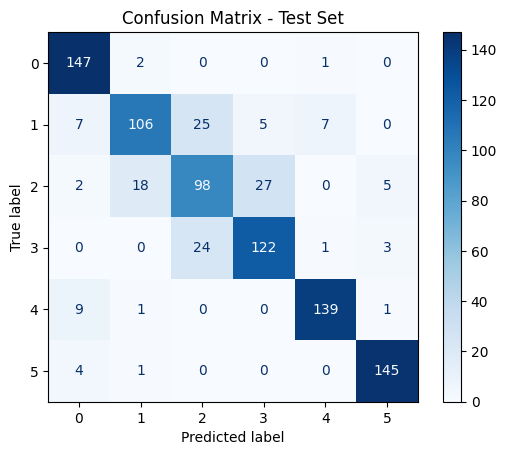


Validation Accuracy: 0.8678


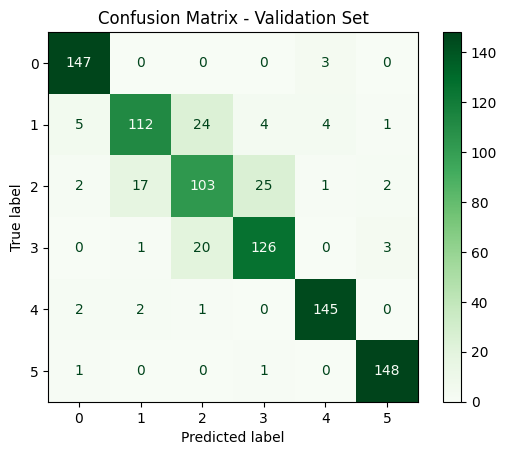

In [ ]:
# 📦 IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 📂 LOAD DATA
# Replace with your path or use Colab file upload
data = pd.read_csv('/content/drive/MyDrive/selected_features/selected_features_shap_penalty.csv')

# 🧹 PREPROCESSING
y = data['label']                      # Assuming column name is 'label'
X = data.drop('label', axis=1)

# If labels are categorical → encode
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# 🔀 SPLIT DATA: 70% train, 15% test, 15% validation

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Temp → 15% test, 15% validation (split Temp 50/50)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Validation size: {len(X_val)}")

# 🤖 TRAIN RANDOM FOREST CLASSIFIER
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 🎯 PREDICT ON TEST SET
y_test_pred = rf.predict(X_test)

# 🎯 PREDICT ON VALIDATION SET
y_val_pred = rf.predict(X_val)

# 📊 EVALUATE: TEST SET
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()

# 📊 EVALUATE: VALIDATION SET
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_acc:.4f}")

cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp_val.plot(cmap='Greens')
plt.title("Confusion Matrix - Validation Set")
plt.show()


In [ ]:
# === MULTI-SEED + MULTI-PENALTY RUNNER ===

import csv
import matplotlib.pyplot as plt

# PARAMETERS:
penalty_list = [0.001, 0.005, 0.01, 0.02, 0.05]  # Penalty values to test
num_seeds = 5  # How many PPO runs per penalty

# OUTPUT CSV:
log_csv_path = os.path.join(output_folder, "ppo_shap_penalty_results_multiseed.csv")

# Write CSV header:
with open(log_csv_path, "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["penalty_coef", "seed", "accuracy", "penalty", "reward", "num_features", "selected_features"])

# LOOP:
for penalty_coef in penalty_list:
    for seed in range(num_seeds):
        print(f"\n==============================")
        print(f"🔥 RUNNING penalty_coef = {penalty_coef} | seed = {seed}")
        print(f"==============================\n")

        # Load data:
        df = pd.read_csv(input_csv_path, header=0)
        X = df.iloc[:, :-1].values.astype(np.float32)
        le = LabelEncoder()
        y = le.fit_transform(df.iloc[:, -1].values)

        # Compute SHAP feature ranks:
        feature_ranks = compute_shap_feature_ranks(X, y)

        # Set PPO seed for reproducibility:
        np.random.seed(seed)

        model, env = train_feature_selector(X, y, feature_ranks, total_timesteps=50000, penalty_coef=penalty_coef)

        obs = env.reset()
        for _ in range(env.n_features):
            mask = np.where(env.selected == 1, 0.0, 1.0)
            action, _ = model.predict(obs, deterministic=True)
            obs, _, done, _ = env.step(action)
            if done:
                break

        selected_idx = np.where(obs == 1)[0]
        X_sel = X[:, selected_idx]

        # Final RF:
        Xtr, Xte, ytr, yte = train_test_split(X_sel, y, test_size=0.3, random_state=0)
        rf_model = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
        rf_model.fit(Xtr, ytr)
        acc = accuracy_score(yte, rf_model.predict(Xte))

        rank_penalty = sum([feature_ranks[int(idx)] for idx in selected_idx])
        penalty = penalty_coef * rank_penalty
        reward = acc - penalty

        # Save selected features CSV:
        df_selected = df.iloc[:, selected_idx.tolist() + [-1]]
        out_path = os.path.join(output_folder, f"selected_features_penalty_{penalty_coef}_seed_{seed}.csv")
        df_selected.to_csv(out_path, index=False)

        print(f"\n✅ Run complete: penalty_coef={penalty_coef}, seed={seed}")
        print(f"Accuracy={acc:.4f}, Penalty={penalty:.4f}, Reward={reward:.4f}, Num_features={len(selected_idx)}")
        print(f"Selected features: {selected_idx.tolist()}")
        print(f"Saved selected features CSV to: {out_path}")

        # Log to CSV:
        with open(log_csv_path, "a", newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow([
                penalty_coef,
                seed,
                acc,
                penalty,
                reward,
                len(selected_idx),
                selected_idx.tolist()
            ])

print("\n==============================")
print(f"✅ All multi-seed runs complete! Results saved to:")
print(f"{log_csv_path}")
print("==============================")




🔥 RUNNING penalty_coef = 0.001 | seed = 0

⚠️ WARNING: SHAP returned 6 features, but X has 38. Fixing...
Using cpu device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
---------------------------------
| rollout/           |          |
|    ep_len_mean    

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=0.7250, Reward=0.1383, Selected=38 features
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 170      |
|    ep_rew_mean     | -1.19    |
| time/              |      

...

[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 180      |
|    ep_rew_mean     | -36.8 

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
---------------------------------
| rollout/        

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
[INFO] Accuracy=0.8633, Penalty=36.2500, Reward=-35.3867, Selected=38 features
---------------------------------
| rollout/        

In [ ]:
#FINAL CODE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 14.0 MB/s eta 0:00:00
📂 Upload your dataset CSV:


Saving balanced_dataset_1000_each1.csv to balanced_dataset_1000_each1.csv

🔥 RUNNING penalty_coef = 0.001

⚠️ WARNING: SHAP returned 6 features, but X has 38. Fixing...
Using cpu device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
[INFO] Acc=0.8633, Penalty=0.0330, Reward=0.8304, Num_features=38
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 154      |
|    ep_rew_mean     | -0.325   |
| time

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


...

[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
[INFO] Acc=0.8633, Penalty=0.3295, Reward=0.5338, Num_features=38
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 151      |
|    ep_rew_mean     | -0.598   |
| time

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
[INFO] Acc=0.8633, Penalty=0.6591, Reward=0.2042, Num_features=38
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 176      |
|    ep_rew_mean     | -1.17    |
| time/              |          |
|    fps             | 81       |
|    iterations      | 1        |
|    time_elapsed    | 25       |
| 

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
[INFO] Acc=0.8633, Penalty=1.6477, Reward=-0.7844, Num_features=38
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 152      |
|    ep_rew_mean     | -1.9

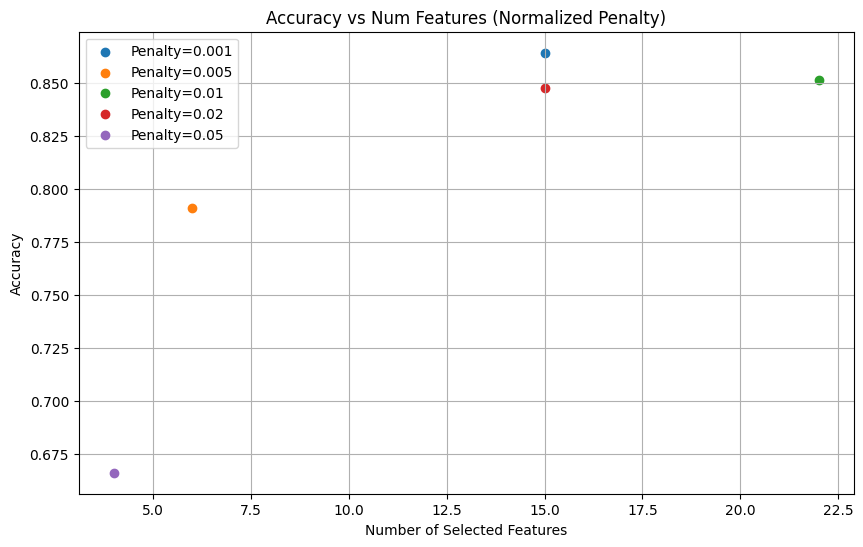

In [ ]:
# === FULL ONE-CELL FOR COLAB ===

# --- INSTALL ---
!pip install -q "stable-baselines3[extra]" shimmy shap scikit-learn pandas matplotlib

# --- IMPORT ---
import os
import csv
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import gym
from gym import spaces

# --- INPUT / OUTPUT PATHS ---
from google.colab import files
print("📂 Upload your dataset CSV:")
uploaded = files.upload()
input_csv_path = list(uploaded.keys())[0]
output_folder = "/content/ppo_selected_features"
os.makedirs(output_folder, exist_ok=True)

# --- PARAMETERS ---
penalty_list = [0.001, 0.005, 0.01, 0.02, 0.05]
total_timesteps = 50000

# --- DATA ---
df = pd.read_csv(input_csv_path, header=0)
X = df.iloc[:, :-1].values.astype(np.float32)
le = LabelEncoder()
y = le.fit_transform(df.iloc[:, -1].values)

# --- OUTPUT CSV ---
log_csv_path = os.path.join(output_folder, "ppo_shap_penalty_results_normalized.csv")
with open(log_csv_path, "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["penalty_coef", "accuracy", "penalty", "reward", "num_features", "selected_features"])

# --- SHAP RANKS ---
def compute_shap_feature_ranks(X, y):
    model = RandomForestClassifier(n_estimators=100, random_state=0)
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    if isinstance(shap_values, list):
        shap_array = np.stack([np.abs(sv) for sv in shap_values], axis=0)
        mean_abs_shap = shap_array.mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_values)
    if mean_abs_shap.ndim == 3:
        mean_abs_shap = mean_abs_shap.mean(axis=1)
    mean_shap_values = np.mean(mean_abs_shap, axis=0)
    if len(mean_shap_values) != X.shape[1]:
        print(f"⚠️ WARNING: SHAP returned {len(mean_shap_values)} features, but X has {X.shape[1]}. Fixing...")
        padded = np.zeros(X.shape[1])
        padded[:len(mean_shap_values)] = mean_shap_values
        mean_shap_values = padded
    feature_ranks = pd.Series(mean_shap_values, index=np.arange(X.shape[1])).rank(ascending=False).astype(int).to_dict()
    max_rank = max(feature_ranks.values())
    feature_ranks_normalized = {k: v / max_rank for k, v in feature_ranks.items()}
    return feature_ranks_normalized

# --- LOOP ---
for penalty_coef in penalty_list:
    print(f"\n==============================")
    print(f"🔥 RUNNING penalty_coef = {penalty_coef}")
    print(f"==============================\n")

    feature_ranks_normalized = compute_shap_feature_ranks(X, y)

    class FeatureSelectionEnvNormalized(gym.Env):
        def __init__(self, X, y, feature_ranks_normalized, penalty_coef=0.0, test_size=0.3, seed=0):
            super().__init__()
            self.X, self.y = X, y
            self.feature_ranks_normalized = feature_ranks_normalized
            self.n_features = X.shape[1]
            self.penalty_coef = penalty_coef
            self.test_size = test_size
            self.random_seed = seed
            self.action_space = spaces.Discrete(self.n_features)
            self.observation_space = spaces.Box(0, 1, (self.n_features,), dtype=np.int8)
            self.reset()

        def reset(self):
            self.selected = np.zeros(self.n_features, dtype=np.int8)
            self.step_count = 0
            return self.selected.copy()

        def step(self, action):
            if self.selected[action]:
                return self.selected.copy(), -0.01, False, {}
            self.selected[action] = 1
            self.step_count += 1
            done = (self.step_count >= self.n_features)
            reward = 0.0
            if done:
                cols = np.where(self.selected == 1)[0]
                if len(cols) == 0:
                    return self.selected.copy(), -1.0, True, {}
                X_sel = self.X[:, cols]
                Xtr, Xte, ytr, yte = train_test_split(X_sel, self.y, test_size=self.test_size, random_state=self.random_seed)
                model = RandomForestClassifier(n_estimators=100, random_state=self.random_seed, n_jobs=-1)
                model.fit(Xtr, ytr)
                acc = accuracy_score(yte, model.predict(Xte))
                rank_penalty = sum([self.feature_ranks_normalized[int(idx)] for idx in cols])
                penalty = self.penalty_coef * rank_penalty
                reward = acc - penalty
                print(f"[INFO] Acc={acc:.4f}, Penalty={penalty:.4f}, Reward={reward:.4f}, Num_features={len(cols)}")
            return self.selected.copy(), reward, done, {}

        def seed(self, seed=None):
            np.random.seed(seed)

    def make_env():
        return FeatureSelectionEnvNormalized(X, y, feature_ranks_normalized, penalty_coef=penalty_coef)

    vec_env = make_vec_env(make_env, n_envs=1)

    model = PPO("MlpPolicy", vec_env, verbose=1, batch_size=128, learning_rate=3e-4)
    model.learn(total_timesteps=total_timesteps)

    obs = vec_env.reset()
    for _ in range(X.shape[1]):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done:
            break

    selected_idx = np.where(obs[0] == 1)[0]
    X_sel = X[:, selected_idx]

    Xtr, Xte, ytr, yte = train_test_split(X_sel, y, test_size=0.3, random_state=0)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    rf_model.fit(Xtr, ytr)
    acc = accuracy_score(yte, rf_model.predict(Xte))

    rank_penalty = sum([feature_ranks_normalized[int(idx)] for idx in selected_idx])
    penalty = penalty_coef * rank_penalty
    reward_val = acc - penalty

    ppo_model_path = os.path.join(output_folder, f"ppo_model_penalty_{penalty_coef}.zip")
    model.save(ppo_model_path)
    print(f"✅ Saved PPO model: {ppo_model_path}")

    df_selected = df.iloc[:, selected_idx.tolist() + [-1]]
    out_path = os.path.join(output_folder, f"selected_features_penalty_{penalty_coef}.csv")
    df_selected.to_csv(out_path, index=False)

    print(f"\n✅ Run complete: penalty_coef={penalty_coef}")
    print(f"Accuracy={acc:.4f}, Penalty={penalty:.4f}, Reward={reward_val:.4f}, Num_features={len(selected_idx)}")
    print(f"Selected features: {selected_idx.tolist()}")
    print(f"Saved selected features CSV to: {out_path}")

    with open(log_csv_path, "a", newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([
            penalty_coef,
            acc,
            penalty,
            reward_val,
            len(selected_idx),
            selected_idx.tolist()
        ])

print("\n==============================")
print(f"✅ All runs complete! Results saved to:")
print(f"{log_csv_path}")
print("==============================")

# --- PLOT ---
results_df = pd.read_csv(log_csv_path)

plt.figure(figsize=(10,6))
for penalty in sorted(results_df['penalty_coef'].unique()):
    subset = results_df[results_df['penalty_coef'] == penalty]
    plt.scatter(subset['num_features'], subset['accuracy'], label=f"Penalty={penalty}")
plt.title("Accuracy vs Num Features (Normalized Penalty)")
plt.xlabel("Number of Selected Features")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import shutil

# Compress the whole output folder:
zip_path = "/content/ppo_selected_features_all.zip"
shutil.make_archive("/content/ppo_selected_features_all", 'zip', output_folder)

# Download the ZIP:
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📂 Upload your dataset CSV:


Saving selected_features_penalty_0.001.csv to selected_features_penalty_0.001 (1).csv
✅ Dataset loaded: selected_features_penalty_0.001 (1).csv
Shape: (6000, 16)
✅ Label encoding applied: ['Sleep stage 1' 'Sleep stage 2' 'Sleep stage 3' 'Sleep stage 4'
 'Sleep stage R' 'Sleep stage W']
✅ Split complete:
Train: 4200 samples
Validation: 900 samples
Test: 900 samples

🎯 Test Accuracy: 88.56%


<Figure size 600x600 with 0 Axes>

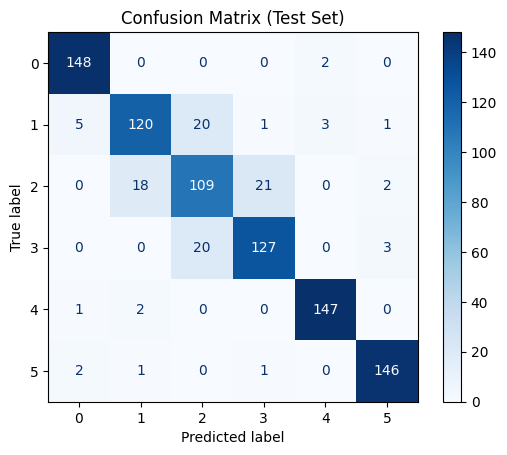

In [ ]:
# === INSTALL (for Colab) ===
!pip install -q scikit-learn matplotlib pandas

# === IMPORT ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from google.colab import files

# === UPLOAD DATASET ===
print("📂 Upload your dataset CSV:")
uploaded = files.upload()
input_csv_path = list(uploaded.keys())[0]

# === LOAD DATA ===
df = pd.read_csv(input_csv_path)
print(f"✅ Dataset loaded: {input_csv_path}")
print(f"Shape: {df.shape}")

# === PREPROCESS ===
X = df.drop('label', axis=1).values.astype(np.float32)
y = df['label'].values

# Label encode if needed:
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f"✅ Label encoding applied: {le.classes_}")

# === SPLIT DATA ===
# First split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Second split: split temp into 50% val, 50% test → gives 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"✅ Split complete:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# === TRAIN RANDOM FOREST ===
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# === EVALUATE ON TEST ===
y_pred_test = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n🎯 Test Accuracy: {test_acc * 100:.2f}%")

# === CONFUSION MATRIX ===
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot:
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Test Set)")
plt.show()


📂 Upload your dataset CSV:


Saving balanced_dataset_1000_each1.csv to balanced_dataset_1000_each1 (7).csv

🔥 RUNNING penalty_coef = 0.001

⚠️ WARNING: SHAP returned 6 features, but X has 38. Fixing...
Using cpu device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
---------------------------------
| rollout/           |          |
|    ep_len_mean    

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


...

[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
---------------------------------
| rollout/           |          |
|    ep_len_mean    

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
------------

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
[INFO] Acc=0.8633, Penalty_SUM_norm=32.9545, Reward=0.6846, Num_features=38
------------

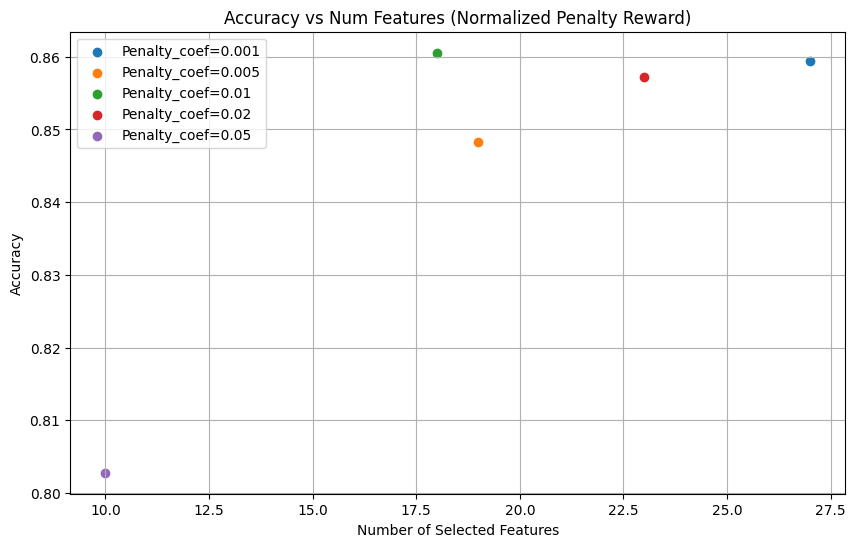

In [ ]:
# === FULL ONE-CELL FOR COLAB: FIXED FOR REQUESTED REWARD ===

# --- INSTALL ---
!pip install -q "stable-baselines3[extra]" shimmy shap scikit-learn pandas matplotlib

# --- IMPORT ---
import os
import csv
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import gym
from gym import spaces

# --- INPUT / OUTPUT PATHS ---
from google.colab import files
print("📂 Upload your dataset CSV:")
uploaded = files.upload()
input_csv_path = list(uploaded.keys())[0]
output_folder = "/content/ppo_selected_features"
os.makedirs(output_folder, exist_ok=True)

# --- PARAMETERS ---
penalty_list = [0.001, 0.005, 0.01, 0.02, 0.05]
total_timesteps = 50000
w1 = 0.8
w2 = 0.2

# --- DATA ---
df = pd.read_csv(input_csv_path, header=0)
X = df.iloc[:, :-1].values.astype(np.float32)
le = LabelEncoder()
y = le.fit_transform(df.iloc[:, -1].values)

# --- OUTPUT CSV ---
log_csv_path = os.path.join(output_folder, "ppo_shap_penalty_results_normalized.csv")
with open(log_csv_path, "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["penalty_coef", "accuracy", "penalty_SUM_normalized", "reward", "num_features", "selected_features"])

# --- SHAP RANKS ---
def compute_shap_feature_ranks(X, y):
    model = RandomForestClassifier(n_estimators=100, random_state=0)
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    if isinstance(shap_values, list):
        shap_array = np.stack([np.abs(sv) for sv in shap_values], axis=0)
        mean_abs_shap = shap_array.mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_values)
    if mean_abs_shap.ndim == 3:
        mean_abs_shap = mean_abs_shap.mean(axis=1)
    mean_shap_values = np.mean(mean_abs_shap, axis=0)
    if len(mean_shap_values) != X.shape[1]:
        print(f"⚠️ WARNING: SHAP returned {len(mean_shap_values)} features, but X has {X.shape[1]}. Fixing...")
        padded = np.zeros(X.shape[1])
        padded[:len(mean_shap_values)] = mean_shap_values
        mean_shap_values = padded
    feature_ranks = pd.Series(mean_shap_values, index=np.arange(X.shape[1])).rank(ascending=False).astype(int).to_dict()
    max_rank = max(feature_ranks.values())
    feature_ranks_normalized = {k: v / max_rank for k, v in feature_ranks.items()}
    return feature_ranks_normalized

# --- LOOP ---
for penalty_coef in penalty_list:
    print(f"\n==============================")
    print(f"🔥 RUNNING penalty_coef = {penalty_coef}")
    print(f"==============================\n")

    feature_ranks_normalized = compute_shap_feature_ranks(X, y)

    class FeatureSelectionEnvNormalized(gym.Env):
        def __init__(self, X, y, feature_ranks_normalized, penalty_coef=0.0, w1=0.8, w2=0.2, test_size=0.3, seed=0):
            super().__init__()
            self.X, self.y = X, y
            self.feature_ranks_normalized = feature_ranks_normalized
            self.n_features = X.shape[1]
            self.penalty_coef = penalty_coef
            self.w1 = w1
            self.w2 = w2
            self.test_size = test_size
            self.random_seed = seed
            self.action_space = spaces.Discrete(self.n_features)
            self.observation_space = spaces.Box(0, 1, (self.n_features,), dtype=np.int8)
            self.reset()

        def reset(self):
            self.selected = np.zeros(self.n_features, dtype=np.int8)
            self.step_count = 0
            return self.selected.copy()

        def step(self, action):
            if self.selected[action]:
                return self.selected.copy(), -0.01, False, {}
            self.selected[action] = 1
            self.step_count += 1
            done = (self.step_count >= self.n_features)
            reward = 0.0
            if done:
                cols = np.where(self.selected == 1)[0]
                if len(cols) == 0:
                    return self.selected.copy(), -1.0, True, {}
                X_sel = self.X[:, cols]
                Xtr, Xte, ytr, yte = train_test_split(X_sel, self.y, test_size=self.test_size, random_state=self.random_seed)
                model = RandomForestClassifier(n_estimators=100, random_state=self.random_seed, n_jobs=-1)
                model.fit(Xtr, ytr)
                acc = accuracy_score(yte, model.predict(Xte))

                # Penalty = sum of normalized ranks → no scaling by penalty_coef
                penalty_sum_normalized = sum([self.feature_ranks_normalized[int(idx)] for idx in cols])
                penalty_sum_normalized = max(penalty_sum_normalized, 1e-6)  # avoid divide by zero

                # Final reward → YOUR REQUESTED FORM:
                reward = self.w1 * acc - self.w2 * (1 / penalty_sum_normalized)

                print(f"[INFO] Acc={acc:.4f}, Penalty_SUM_norm={penalty_sum_normalized:.4f}, Reward={reward:.4f}, Num_features={len(cols)}")
            return self.selected.copy(), reward, done, {}

        def seed(self, seed=None):
            np.random.seed(seed)

    def make_env():
        return FeatureSelectionEnvNormalized(X, y, feature_ranks_normalized, penalty_coef=penalty_coef, w1=w1, w2=w2)

    vec_env = make_vec_env(make_env, n_envs=1)

    model = PPO("MlpPolicy", vec_env, verbose=1, batch_size=128, learning_rate=3e-4)
    model.learn(total_timesteps=total_timesteps)

    obs = vec_env.reset()
    for _ in range(X.shape[1]):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done:
            break

    selected_idx = np.where(obs[0] == 1)[0]
    X_sel = X[:, selected_idx]

    Xtr, Xte, ytr, yte = train_test_split(X_sel, y, test_size=0.3, random_state=0)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    rf_model.fit(Xtr, ytr)
    acc = accuracy_score(yte, rf_model.predict(Xte))

    penalty_sum_normalized = sum([feature_ranks_normalized[int(idx)] for idx in selected_idx])
    penalty_sum_normalized = max(penalty_sum_normalized, 1e-6)

    reward_val = w1 * acc - w2 * (1 / penalty_sum_normalized)

    ppo_model_path = os.path.join(output_folder, f"ppo_model_penalty_{penalty_coef}.zip")
    model.save(ppo_model_path)
    print(f"✅ Saved PPO model: {ppo_model_path}")

    df_selected = df.iloc[:, selected_idx.tolist() + [-1]]
    out_path = os.path.join(output_folder, f"selected_features_penalty_{penalty_coef}.csv")
    df_selected.to_csv(out_path, index=False)

    print(f"\n✅ Run complete: penalty_coef={penalty_coef}")
    print(f"Accuracy={acc:.4f}, Penalty_SUM_norm={penalty_sum_normalized:.4f}, Reward={reward_val:.4f}, Num_features={len(selected_idx)}")
    print(f"Selected features: {selected_idx.tolist()}")
    print(f"Saved selected features CSV to: {out_path}")

    with open(log_csv_path, "a", newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([
            penalty_coef,
            acc,
            penalty_sum_normalized,
            reward_val,
            len(selected_idx),
            selected_idx.tolist()
        ])

print("\n==============================")
print(f"✅ All runs complete! Results saved to:")
print(f"{log_csv_path}")
print("==============================")

# --- PLOT ---
results_df = pd.read_csv(log_csv_path)

plt.figure(figsize=(10,6))
for penalty in sorted(results_df['penalty_coef'].unique()):
    subset = results_df[results_df['penalty_coef'] == penalty]
    plt.scatter(subset['num_features'], subset['accuracy'], label=f"Penalty_coef={penalty}")
plt.title("Accuracy vs Num Features (Normalized Penalty Reward)")
plt.xlabel("Number of Selected Features")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# === FULL ONE-CELL TUNED VERSION FOR COLAB ===

# --- INSTALL ---
!pip install -q "stable-baselines3[extra]" shimmy shap scikit-learn pandas matplotlib

# --- IMPORT ---
import os
import csv
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import gym
from gym import spaces

# --- INPUT / OUTPUT PATHS ---
from google.colab import files
print("📂 Upload your dataset CSV:")
uploaded = files.upload()
input_csv_path = list(uploaded.keys())[0]
output_folder = "/content/ppo_selected_features"
os.makedirs(output_folder, exist_ok=True)

# --- PARAMETERS ---
penalty_list = [0.001, 0.005, 0.01, 0.02, 0.05]
total_timesteps = 200000  # TUNED → was 50k
w1 = 0.8
w2 = 0.2

# PPO TUNING
ppo_batch_size = 256
ppo_learning_rate = 1e-4
ppo_net_arch = [128, 128, 64]

# RF TUNING
rf_n_estimators = 300

# --- DATA ---
df = pd.read_csv(input_csv_path, header=0)
X = df.iloc[:, :-1].values.astype(np.float32)
le = LabelEncoder()
y = le.fit_transform(df.iloc[:, -1].values)

# --- OUTPUT CSV ---
log_csv_path = os.path.join(output_folder, "ppo_shap_penalty_results_normalized.csv")
with open(log_csv_path, "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["penalty_coef", "accuracy", "penalty_SUM_normalized", "reward", "num_features", "selected_features"])

# --- SHAP RANKS ---
def compute_shap_feature_ranks(X, y):
    model = RandomForestClassifier(n_estimators=rf_n_estimators, random_state=0)
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    if isinstance(shap_values, list):
        shap_array = np.stack([np.abs(sv) for sv in shap_values], axis=0)
        mean_abs_shap = shap_array.mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_values)
    if mean_abs_shap.ndim == 3:
        mean_abs_shap = mean_abs_shap.mean(axis=1)
    mean_shap_values = np.mean(mean_abs_shap, axis=0)
    if len(mean_shap_values) != X.shape[1]:
        print(f"⚠️ WARNING: SHAP returned {len(mean_shap_values)} features, but X has {X.shape[1]}. Fixing...")
        padded = np.zeros(X.shape[1])
        padded[:len(mean_shap_values)] = mean_shap_values
        mean_shap_values = padded
    feature_ranks = pd.Series(mean_shap_values, index=np.arange(X.shape[1])).rank(ascending=False).astype(int).to_dict()
    max_rank = max(feature_ranks.values())
    feature_ranks_normalized = {k: v / max_rank for k, v in feature_ranks.items()}
    return feature_ranks_normalized

# --- LOOP ---
for penalty_coef in penalty_list:
    print(f"\n==============================")
    print(f"🔥 RUNNING penalty_coef = {penalty_coef}")
    print(f"==============================\n")

    feature_ranks_normalized = compute_shap_feature_ranks(X, y)

    class FeatureSelectionEnvNormalized(gym.Env):
        def __init__(self, X, y, feature_ranks_normalized, penalty_coef=0.0, w1=0.8, w2=0.2, test_size=0.3, seed=0):
            super().__init__()
            self.X, self.y = X, y
            self.feature_ranks_normalized = feature_ranks_normalized
            self.n_features = X.shape[1]
            self.penalty_coef = penalty_coef
            self.w1 = w1
            self.w2 = w2
            self.test_size = test_size
            self.random_seed = seed
            self.action_space = spaces.Discrete(self.n_features)
            self.observation_space = spaces.Box(0, 1, (self.n_features,), dtype=np.int8)
            self.reset()

        def reset(self):
            self.selected = np.zeros(self.n_features, dtype=np.int8)
            self.step_count = 0
            return self.selected.copy()

        def step(self, action):
            if self.selected[action]:
                return self.selected.copy(), -0.01, False, {}
            self.selected[action] = 1
            self.step_count += 1
            done = (self.step_count >= self.n_features)
            reward = 0.0
            if done:
                cols = np.where(self.selected == 1)[0]
                if len(cols) == 0:
                    return self.selected.copy(), -1.0, True, {}
                X_sel = self.X[:, cols]
                Xtr, Xte, ytr, yte = train_test_split(X_sel, self.y, test_size=self.test_size, random_state=self.random_seed)
                model = RandomForestClassifier(n_estimators=rf_n_estimators, random_state=self.random_seed, n_jobs=-1)
                model.fit(Xtr, ytr)
                acc = accuracy_score(yte, model.predict(Xte))

                penalty_sum_normalized = sum([self.feature_ranks_normalized[int(idx)] for idx in cols])
                penalty_sum_normalized = max(penalty_sum_normalized, 1e-6)

                reward = self.w1 * acc - self.w2 * (1 / penalty_sum_normalized)

                print(f"[INFO] Acc={acc:.4f}, Penalty_SUM_norm={penalty_sum_normalized:.4f}, Reward={reward:.4f}, Num_features={len(cols)}")
            return self.selected.copy(), reward, done, {}

        def seed(self, seed=None):
            np.random.seed(seed)

    def make_env():
        return FeatureSelectionEnvNormalized(X, y, feature_ranks_normalized, penalty_coef=penalty_coef, w1=w1, w2=w2)

    vec_env = make_vec_env(make_env, n_envs=1)

    policy_kwargs = dict(net_arch=ppo_net_arch)
    model = PPO("MlpPolicy", vec_env, verbose=1, batch_size=ppo_batch_size, learning_rate=ppo_learning_rate, policy_kwargs=policy_kwargs)
    model.learn(total_timesteps=total_timesteps)

    obs = vec_env.reset()
    for _ in range(X.shape[1]):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done:
            break

    selected_idx = np.where(obs[0] == 1)[0]
    X_sel = X[:, selected_idx]

    Xtr, Xte, ytr, yte = train_test_split(X_sel, y, test_size=0.3, random_state=0)
    rf_model = RandomForestClassifier(n_estimators=rf_n_estimators, random_state=0, n_jobs=-1)
    rf_model.fit(Xtr, ytr)
    acc = accuracy_score(yte, rf_model.predict(Xte))

    penalty_sum_normalized = sum([feature_ranks_normalized[int(idx)] for idx in selected_idx])
    penalty_sum_normalized = max(penalty_sum_normalized, 1e-6)

    reward_val = w1 * acc - w2 * (1 / penalty_sum_normalized)

    ppo_model_path = os.path.join(output_folder, f"ppo_model_penalty_{penalty_coef}.zip")
    model.save(ppo_model_path)
    print(f"✅ Saved PPO model: {ppo_model_path}")

    df_selected = df.iloc[:, selected_idx.tolist() + [-1]]
    out_path = os.path.join(output_folder, f"selected_features_penalty_{penalty_coef}.csv")
    df_selected.to_csv(out_path, index=False)

    print(f"\n✅ Run complete: penalty_coef={penalty_coef}")
    print(f"Accuracy={acc:.4f}, Penalty_SUM_norm={penalty_sum_normalized:.4f}, Reward={reward_val:.4f}, Num_features={len(selected_idx)}")
    print(f"Selected features: {selected_idx.tolist()}")
    print(f"Saved selected features CSV to: {out_path}")

    with open(log_csv_path, "a", newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([
            penalty_coef,
            acc,
            penalty_sum_normalized,
            reward_val,
            len(selected_idx),
            selected_idx.tolist()
        ])

print("\n==============================")
print(f"✅ All runs complete! Results saved to:")
print(f"{log_csv_path}")
print("==============================")

# --- PLOT ---
results_df = pd.read_csv(log_csv_path)

plt.figure(figsize=(10,6))
for penalty in sorted(results_df['penalty_coef'].unique()):
    subset = results_df[results_df['penalty_coef'] == penalty]
    plt.scatter(subset['num_features'], subset['accuracy'], label=f"Penalty_coef={penalty}")
plt.title("Accuracy vs Num Features (TUNED PPO + RF + SHAP)")
plt.xlabel("Number of Selected Features")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


📂 Upload your dataset CSV:


Saving balanced_dataset_1000_each1.csv to balanced_dataset_1000_each1 (9).csv

🔥 RUNNING penalty_coef = 0.001

⚠️ WARNING: SHAP returned 6 features, but X has 38. Fixing...
Using cpu device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0.8694, Penalty_SUM_norm=32.9545, Reward=0.6895, Num_features=38
[INFO] Acc=0

📂 Upload your dataset CSV:


Saving selected_features_penalty_0.01.csv to selected_features_penalty_0.01 (1).csv
✅ Dataset loaded: selected_features_penalty_0.01 (1).csv
Shape: (6000, 19)
✅ Label encoding applied: ['Sleep stage 1' 'Sleep stage 2' 'Sleep stage 3' 'Sleep stage 4'
 'Sleep stage R' 'Sleep stage W']
✅ Split complete:
Train: 4200 samples
Validation: 900 samples
Test: 900 samples

🎯 Test Accuracy: 88.56%
📋 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       150
           1       0.88      0.79      0.83       150
           2       0.75      0.75      0.75       150
           3       0.83      0.86      0.84       150
           4       0.95      0.97      0.96       150
           5       0.95      0.97      0.96       150

    accuracy                           0.89       900
   macro avg       0.89      0.89      0.88       900
weighted avg       0.89      0.89      0.88       900

🧩 Confusion Matrix:
 [[147   0   0   0   3

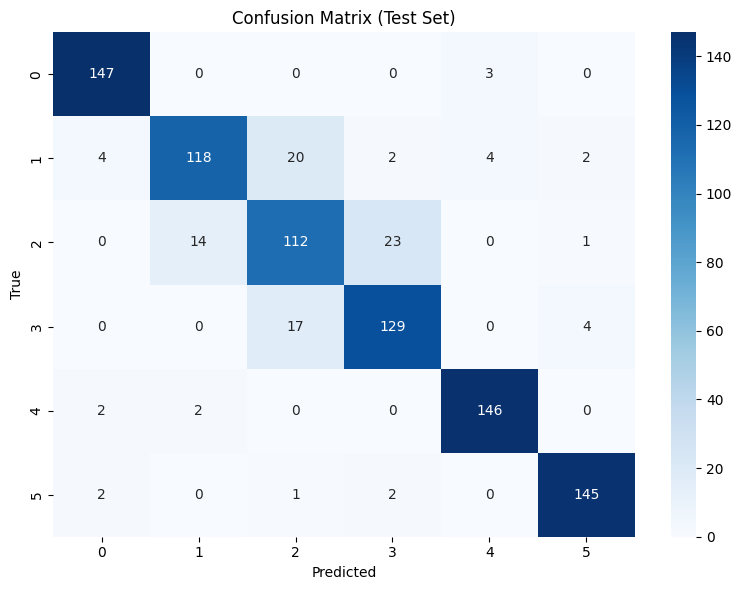

In [ ]:
# === INSTALL (for Colab) ===
!pip install -q scikit-learn matplotlib pandas

# === IMPORT ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from google.colab import files

# === SET SEED FOR FULL REPRODUCIBILITY ===
np.random.seed(42)

# === UPLOAD DATASET ===
print("📂 Upload your dataset CSV:")
uploaded = files.upload()
input_csv_path = list(uploaded.keys())[0]

# === LOAD DATA ===
df = pd.read_csv(input_csv_path)
print(f"✅ Dataset loaded: {input_csv_path}")
print(f"Shape: {df.shape}")

# === PREPROCESS ===
X = df.drop('label', axis=1).values.astype(np.float32)
y = df['label'].values

# Label encode if needed:
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f"✅ Label encoding applied: {le.classes_}")

# === SPLIT DATA ===
# First split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Second split: split temp into 50% val, 50% test → gives 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"✅ Split complete:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# === TRAIN RANDOM FOREST ===
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,        # full parallelism
    bootstrap=True,   # default True, explicit for clarity
    oob_score=False   # out-of-bag not used here
)
rf_model.fit(X_train, y_train)

# === EVALUATE ON TEST ===
y_pred_test = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
report = classification_report(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

print(f"\n🎯 Test Accuracy: {test_acc * 100:.2f}%")
print("📋 Classification Report:\n", report)
print("🧩 Confusion Matrix:\n", cm)

# === CONFUSION MATRIX HEATMAP ===
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()
